In [9]:
"""
Traffic Prediction - Data Exploration
January 2023 BASt Data
Author: Tulsi
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append('..')
import config

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Traffic Volume Prediction - Data Exploration")
print("=" * 60)

Traffic Volume Prediction - Data Exploration


In [10]:
# Load clean data
data_file = Path(config.PROCESSED_DATA_DIR) / "traffic_2023_01_clean.csv"
df = pd.read_csv(data_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (744, 5)
Date Range: 2023-01-01 00:00:00 to 2023-01-31 23:00:00

Columns: ['timestamp', 'PKW', 'LKW', 'Buses', 'Total']

First 5 rows:


,timestamp,PKW,LKW,Buses,Total
0,2023-01-01 00:00:00,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,1.0,26.0,2.0,44.0
2,2023-01-01 02:00:00,0.0,97.0,3.0,85.0
3,2023-01-01 03:00:00,1.0,85.0,5.0,75.0
4,2023-01-01 04:00:00,0.0,41.0,2.0,63.0


In [11]:
# Statistics
print("Traffic Statistics:")
df[['PKW', 'LKW', 'Buses', 'Total']].describe()

Traffic Statistics:


,PKW,LKW,Buses,Total
count,743.000000,743.000000,743.000000,743.000000
mean,145.245626,447.199192,230.071332,422.670929
std,136.967358,283.675462,212.685207,152.654621
min,0.000000,19.000000,0.000000,44.000000
25%,33.000000,181.500000,31.000000,303.000000
50%,104.000000,453.000000,177.000000,454.000000
75%,230.500000,666.000000,393.500000,539.000000
max,556.000000,1292.000000,912.000000,834.000000


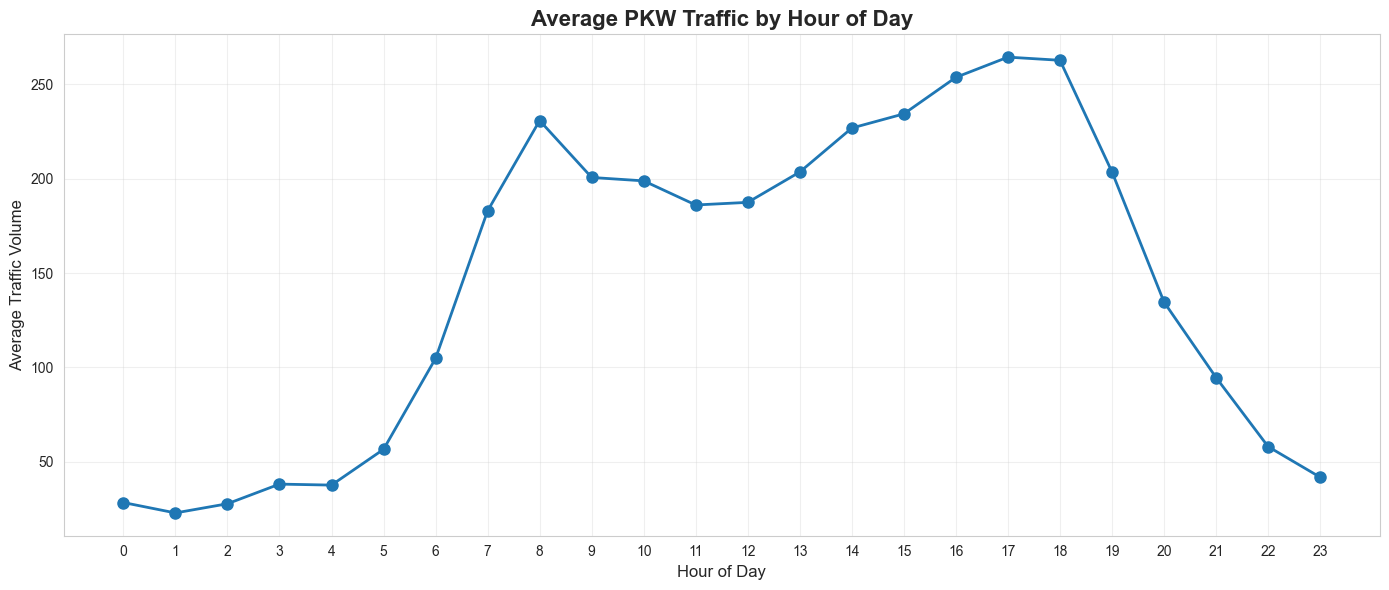

In [12]:
# Hourly patterns
df['hour'] = df['timestamp'].dt.hour

plt.figure(figsize=(14, 6))
hourly_avg = df.groupby('hour')['PKW'].mean()
plt.plot(hourly_avg, marker='o', linewidth=2, markersize=8)
plt.title('Average PKW Traffic by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Traffic Volume', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

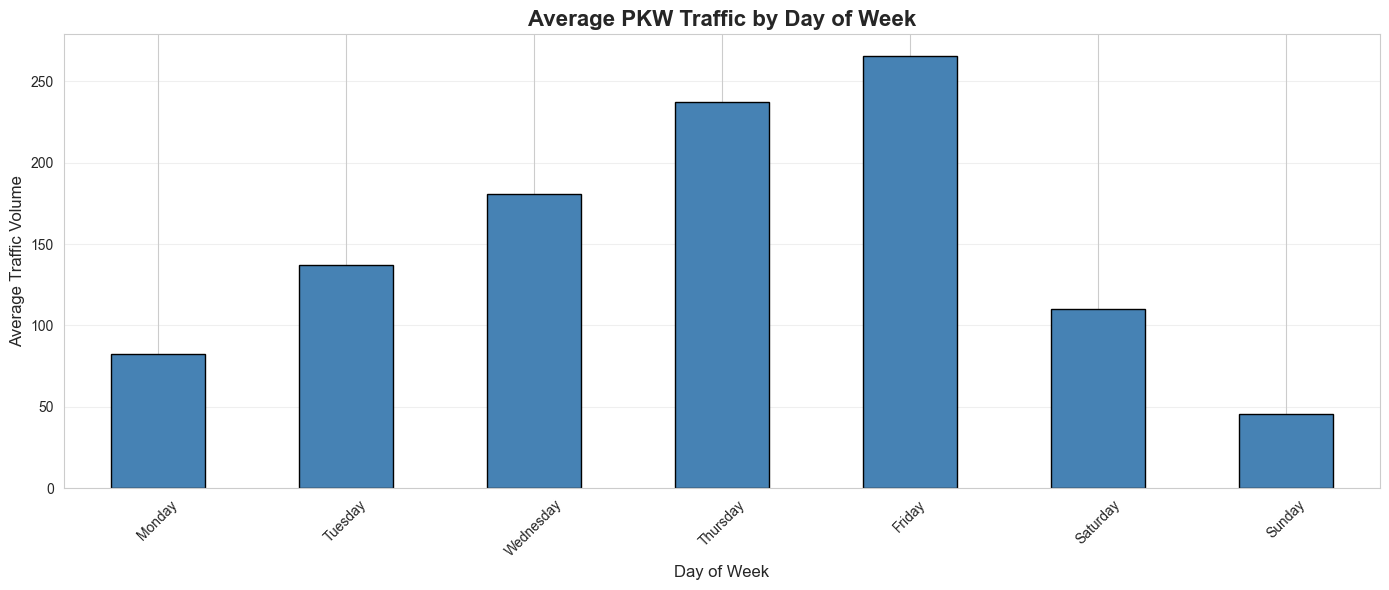

In [13]:
# Weekly patterns
df['day_of_week'] = df['timestamp'].dt.day_name()

plt.figure(figsize=(14, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_of_week')['PKW'].mean().reindex(day_order)
daily_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average PKW Traffic by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Traffic Volume', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

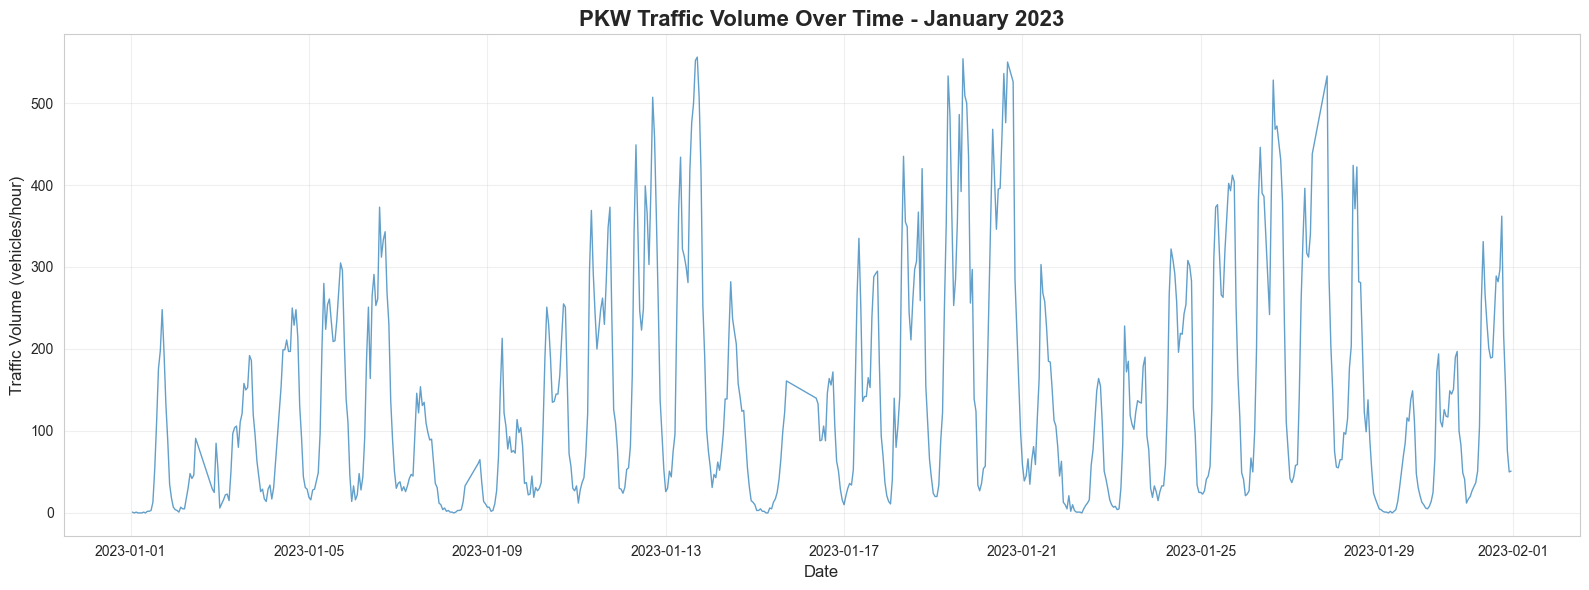

In [14]:
# Time series plot
plt.figure(figsize=(16, 6))
plt.plot(df['timestamp'], df['PKW'], alpha=0.7, linewidth=1)
plt.title('PKW Traffic Volume Over Time - January 2023', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Traffic Volume (vehicles/hour)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

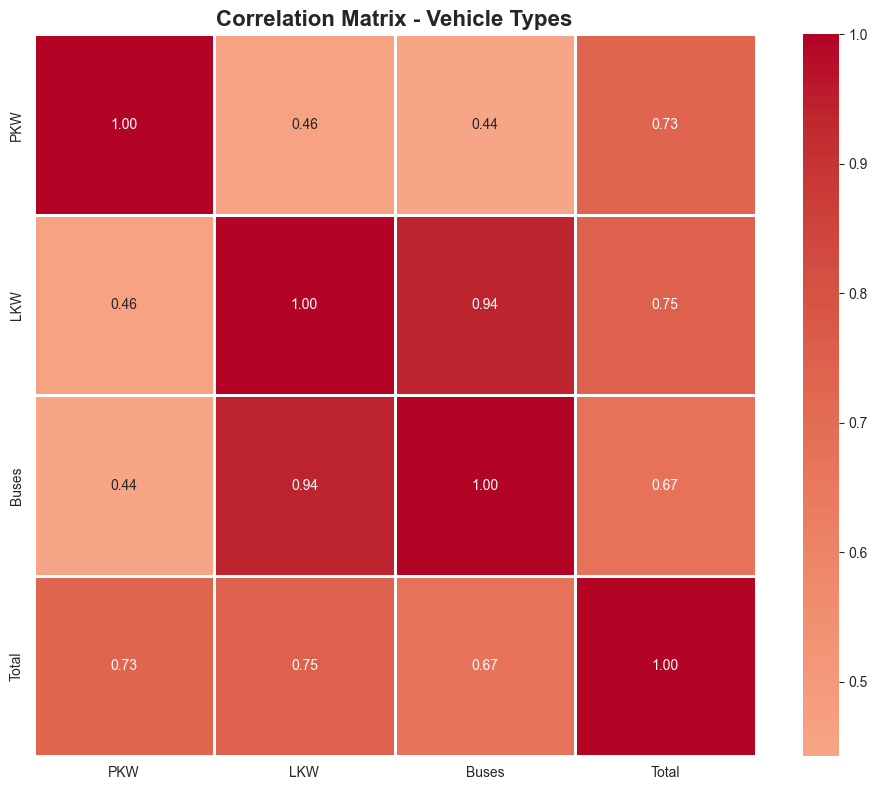

In [15]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[['PKW', 'LKW', 'Buses', 'Total']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix - Vehicle Types', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()